# Exploratory Data Analysis — DENTEX Diagnosis Dataset

After dataset construction and validation, this notebook performs exploratory data analysis of the canonical processed DENTEX diagnosis dataset. The purpose is to investigate data properties that may directly affect detector training and evaluation: class distribution, objects per image, image geometry, bounding-box geometry, small objects, spatial location, annotation quality, and consistency across train, validation, and test.

EDA is used not only to describe the dataset, but also to support later decisions about preprocessing, augmentation, input resolution, training stability, evaluation metrics, model comparison, and error analysis. It remains descriptive and diagnostic: no annotations or split assignments are changed, and no model is trained or selected here.

The test subset is not used for model fitting, architecture selection, hyperparameter tuning, or refinement. Aggregate dataset-level statistics may still be inspected during integrity checks and descriptive EDA.

## 1. Dataset Loading and EDA Setup

The source of truth for this analysis is the canonical processed dataset created by `00_prepare_dataset.ipynb` under `data/processed/dentex_diagnosis/`. The notebook loads `train.json`, `val.json`, and `test.json` together with their corresponding image directories. These COCO-compatible files already contain the fixed split and the project-specific four-class diagnosis labels.

The loader converts image and annotation records into analysis tables. For each box it derives pixel area, relative area, normalized width and height, box aspect ratio, and normalized center coordinates. These are analytical columns only; source JSON files, image files, annotations, and split membership remain unchanged.

In [1]:
from collections import Counter, defaultdict
import json
from pathlib import Path
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

RANDOM_SEED = 42
SPLIT_ORDER = ["train", "val", "test"]
CLASS_NAMES = {0: "Impacted", 1: "Caries", 2: "Periapical Lesion", 3: "Deep Caries"}
CLASS_COLORS = {0: "#e76f51", 1: "#2a9d8f", 2: "#e9c46a", 3: "#457b9d"}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "data" / "processed" / "dentex_diagnosis").is_dir() else cwd.parent
DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "dentex_diagnosis"
ANNOTATION_ROOT = DATA_ROOT / "annotations"
IMAGE_ROOT = DATA_ROOT / "images"

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_ROOT}")

display(pd.DataFrame({"Value": [DATA_ROOT, RANDOM_SEED]}, index=["Canonical dataset", "Random seed"]))

,Value
Canonical dataset,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
Random seed,42


In [2]:
def load_split_records(split):
    """Load one processed COCO split and derive image- and box-level EDA records."""
    annotation_path = ANNOTATION_ROOT / f"{split}.json"
    with annotation_path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    categories = {int(item["id"]): item["name"] for item in payload["categories"]}
    if categories != CLASS_NAMES:
        raise RuntimeError(f"Unexpected categories in {split}: {categories}")

    split_images = {int(item["id"]): item for item in payload["images"]}
    image_records = [{
        "split": split,
        "image_id": int(image["id"]),
        "file_name": image["file_name"],
        "width": int(image["width"]),
        "height": int(image["height"]),
        "image_path": IMAGE_ROOT / split / image["file_name"],
    } for image in payload["images"]]

    annotation_records = []
    for annotation in payload["annotations"]:
        image = split_images[int(annotation["image_id"])]
        x, y, box_width, box_height = map(float, annotation["bbox"])
        image_width, image_height = int(image["width"]), int(image["height"])
        box_area = box_width * box_height
        annotation_records.append({
            "split": split,
            "annotation_id": int(annotation["id"]),
            "image_id": int(annotation["image_id"]),
            "file_name": image["file_name"],
            "class_id": int(annotation["category_id"]),
            "class_name": categories[int(annotation["category_id"])],
            "image_width": image_width,
            "image_height": image_height,
            "x": x,
            "y": y,
            "bbox_width": box_width,
            "bbox_height": box_height,
            "bbox_area": box_area,
            "relative_area": box_area / (image_width * image_height),
            "normalized_width": box_width / image_width,
            "normalized_height": box_height / image_height,
            "bbox_aspect_ratio": box_width / box_height,
            "center_x": (x + box_width / 2) / image_width,
            "center_y": (y + box_height / 2) / image_height,
        })
    return payload, image_records, annotation_records


def load_processed_dataset():
    payloads, image_rows, annotation_rows = {}, [], []
    for split in SPLIT_ORDER:
        payload, split_images, split_annotations = load_split_records(split)
        payloads[split] = payload
        image_rows.extend(split_images)
        annotation_rows.extend(split_annotations)

    images = pd.DataFrame(image_rows)
    annotations = pd.DataFrame(annotation_rows)
    object_counts = annotations.groupby(["split", "image_id"]).size().rename("num_objects")
    images = images.join(object_counts, on=["split", "image_id"])
    images["num_objects"] = images["num_objects"].fillna(0).astype(int)
    images["aspect_ratio"] = images["width"] / images["height"]
    for class_id in CLASS_NAMES:
        present_ids = set(annotations.loc[annotations["class_id"] == class_id, "image_id"])
        images[f"has_{class_id}"] = images["image_id"].isin(present_ids).astype(int)
    return payloads, images, annotations

In [3]:
payloads, images_df, annotations_df = load_processed_dataset()

dataset_overview = pd.DataFrame({
    "Images": images_df.groupby("split").size(),
    "Annotations": annotations_df.groupby("split").size(),
    "Mean objects per image": images_df.groupby("split")["num_objects"].mean(),
}).reindex(SPLIT_ORDER)
dataset_overview.loc["total"] = [len(images_df), len(annotations_df), images_df["num_objects"].mean()]
category_table = pd.DataFrame([{"Class ID": class_id, "Class name": name} for class_id, name in CLASS_NAMES.items()])
display(dataset_overview)
display(category_table)

,Images,Annotations,Mean objects per image
split,,,
train,493.0000,"2,442.0000",4.9533
val,106.0000,548.0000,5.1698
test,106.0000,539.0000,5.0849
total,705.0000,"3,529.0000",5.0057


,Class ID,Class name
0,0,Impacted
1,1,Caries
2,2,Periapical Lesion
3,3,Deep Caries


**Observation and implication.** The three canonical splits contain 705 images and 3,529 annotations in total, with the expected class mapping. Train contains 493 images and 2,442 annotations, validation contains 106 images and 548 annotations, and test contains 106 images and 539 annotations. The difference between annotation counts reflects variation in objects per image rather than a split-size error. These fixed records are used throughout the remaining EDA.

## 2. Class Distribution

For object detection, class distribution must be examined at two levels. The annotation-level count measures individual labelled objects. Image-level presence measures how many radiographs contain at least one object of a class; it matters because one panorama may contain several objects of the same class and may also contain several different classes.

The two counts therefore answer different questions: instance counts describe the amount of object-level supervision, while presence counts describe how broadly each diagnosis is distributed across images. Image-level counts are not expected to sum to 705 because the same image can contribute to multiple classes.

In [4]:
def analyze_class_distribution(annotations):
    """Class distribution and display its tables and visualizations."""
    instance_counts = pd.crosstab(annotations["class_name"], annotations["split"]).reindex(
        index=CLASS_NAMES.values(), columns=SPLIT_ORDER, fill_value=0
    )
    instance_counts["total"] = instance_counts.sum(axis=1)

    presence_source = annotations.drop_duplicates(["split", "image_id", "class_name"])
    presence_counts = pd.crosstab(presence_source["class_name"], presence_source["split"]).reindex(
        index=CLASS_NAMES.values(), columns=SPLIT_ORDER, fill_value=0
    )
    presence_counts["total"] = presence_counts.sum(axis=1)

    display(instance_counts)
    display(presence_counts)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    instance_counts[SPLIT_ORDER].plot(kind="bar", ax=axes[0], color=["#264653", "#2a9d8f", "#e9c46a"])
    axes[0].set(title="Annotation instances by class and split", xlabel="", ylabel="Annotations")
    axes[0].tick_params(axis="x", rotation=25)
    presence_counts[SPLIT_ORDER].plot(kind="bar", ax=axes[1], color=["#264653", "#2a9d8f", "#e9c46a"])
    axes[1].set(title="Images containing each class", xlabel="", ylabel="Images")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
    return instance_counts, presence_counts

split,train,val,test,total
class_name,,,,
Impacted,409,99,96,604
Caries,1501,355,333,2189
Periapical Lesion,109,23,26,158
Deep Caries,423,71,84,578


split,train,val,test,total
class_name,,,,
Impacted,178,38,38,254
Caries,436,93,94,623
Periapical Lesion,80,18,18,116
Deep Caries,225,48,48,321


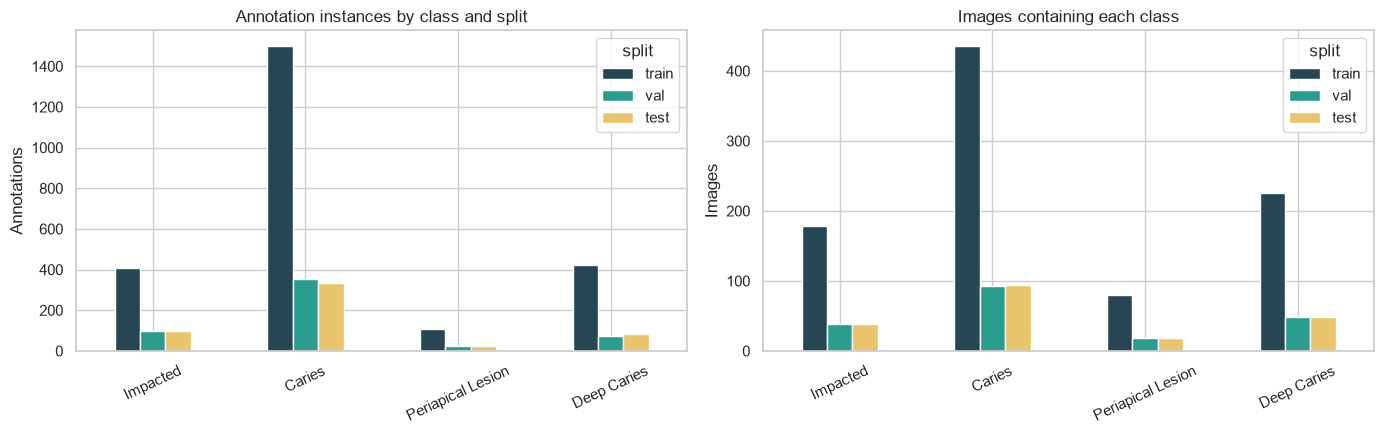

In [5]:
instance_counts, presence_counts = analyze_class_distribution(annotations_df)

**Observation.** The dataset contains 3,529 annotated objects. Caries is the dominant category with 2,189 annotations across 623 images, or approximately

$$
\frac{2189}{3529}\times 100\% \approx 62.0\%.
$$

Impacted and Deep Caries have similar, substantially smaller instance counts: 604 and 578 annotations, occurring in 254 and 321 images respectively. Periapical Lesion is the rarest class, with only 158 annotations across 116 images. The instance-level imbalance between the most and least represented classes is

$$
\frac{N_{\mathrm{Caries}}}{N_{\mathrm{Periapical\ Lesion}}}
= \frac{2189}{158} \approx 13.9.
$$

**Modeling implication.** Caries contributes much more supervision than Periapical Lesion, so rare-class performance may be lower and more variable. Aggregate mAP alone can conceal weak performance on an underrepresented class; later evaluation should include per-class AP and recall-oriented diagnostics, especially for Periapical Lesion. Imbalance alone does not justify automatically applying class weighting, oversampling, resampling, or a specialised loss. Such interventions should be considered only after observing baseline behaviour and actual error patterns.

## 3. Objects per Image

Object density indicates how much the complexity of individual radiographs varies. It also identifies images without target objects and densely annotated cases. For image $i$, let $N_i$ denote the number of target annotations. Images with $N_i=0$ are valid negative images: the correct detector behaviour is to produce no target-class detections.

In [6]:
def analyze_object_density(images):
    """Object density and display its tables and visualizations."""
    object_summary = images.groupby("split")["num_objects"].describe()[
        ["count", "min", "mean", "50%", "max", "std"]
    ].rename(columns={"50%": "median"}).reindex(SPLIT_ORDER)
    object_summary.loc["overall"] = images["num_objects"].describe()[
        ["count", "min", "mean", "50%", "max", "std"]
    ].rename({"50%": "median"})

    zero_counts = images.assign(zero_objects=images["num_objects"].eq(0)).groupby("split")["zero_objects"].sum()
    display(object_summary)
    display(zero_counts.rename("zero_annotation_images").to_frame())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    bins = np.arange(images["num_objects"].max() + 2) - 0.5
    sns.histplot(data=images, x="num_objects", bins=bins, ax=axes[0], color="#457b9d")
    axes[0].set(title="Objects per image", xlabel="Annotated objects", ylabel="Images")
    sns.boxplot(data=images, x="split", y="num_objects", order=SPLIT_ORDER, ax=axes[1], color="#a8dadc")
    axes[1].set(title="Object density by split", xlabel="Split", ylabel="Objects per image")
    plt.tight_layout()
    plt.show()
    return object_summary, zero_counts

,count,min,mean,median,max,std
split,,,,,,
train,493.0000,0.0000,4.9533,4.0000,21.0000,3.3184
val,106.0000,0.0000,5.1698,4.0000,23.0000,3.7224
test,106.0000,0.0000,5.0849,4.0000,17.0000,3.5163
overall,705.0000,0.0000,5.0057,4.0000,23.0000,3.4079


,zero_annotation_images
split,
test,4
train,19
val,4


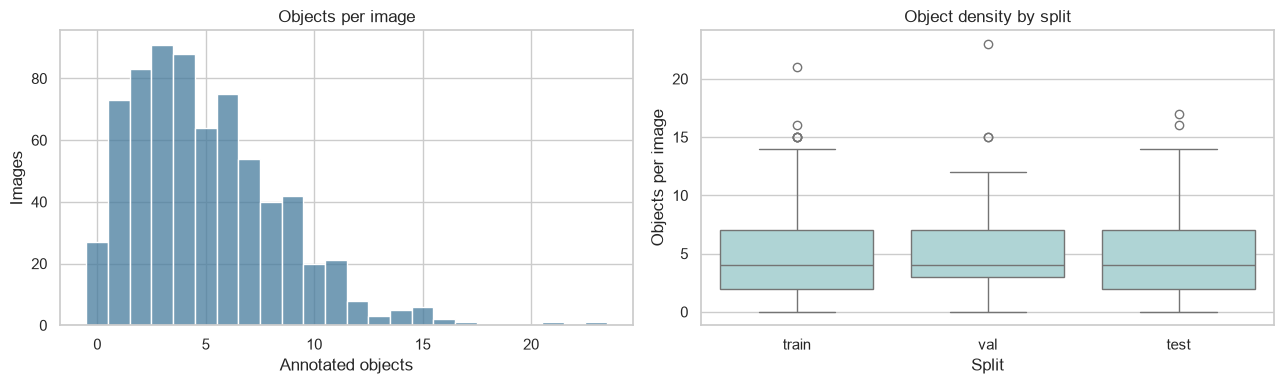

In [7]:
object_summary, zero_counts = analyze_object_density(images_df)

**Observation.** The number of annotated objects ranges from 0 to 23 per image. The overall mean is approximately 5.01 and the median is 4. Because the mean exceeds the median, the distribution is right-skewed by a smaller number of densely annotated radiographs. The dataset contains 27 negative images: 19 in train, 4 in validation, and 4 in test.

**Modeling implication.** Negative images are not annotation errors and should not be removed automatically. They expose the detector to target-absent cases and later support focused false-positive analysis. At the other end of the distribution, dense images are more difficult because many objects must be localised and classified simultaneously. They should be retained and revisited during error analysis to determine whether missed or poorly localised objects increase with annotation density.

## 4. Image Resolution and Aspect Ratio

DENTEX panoramas do not share a single resolution. Resolution and aspect ratio directly affect preprocessing because detector inputs must eventually be mapped to architecture-compatible dimensions. For image $i$, aspect ratio is

$$
r_i = \frac{W_i}{H_i},
$$

where $W_i$ and $H_i$ are image width and height. Comparing both absolute dimensions and their ratio establishes whether a single direct square resize would preserve the original geometry.

In [8]:
def analyze_image_resolutions(images):
    """Image resolutions and display its tables and visualizations."""
    resolution_summary = images[["width", "height", "aspect_ratio"]].describe().T[
        ["min", "25%", "50%", "mean", "75%", "max"]
    ]
    common_resolutions = (
        images.groupby(["width", "height"]).size().rename("images").sort_values(ascending=False).head(10).reset_index()
    )
    display(resolution_summary)
    display(common_resolutions)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.scatterplot(data=images, x="width", y="height", hue="split", hue_order=SPLIT_ORDER, alpha=0.65, ax=axes[0])
    axes[0].set(title="Image dimensions", xlabel="Width (px)", ylabel="Height (px)")
    sns.histplot(data=images, x="aspect_ratio", hue="split", hue_order=SPLIT_ORDER, element="step", stat="density", common_norm=False, ax=axes[1])
    axes[1].set(title="Image aspect-ratio distribution", xlabel="Width / height", ylabel="Density")
    plt.tight_layout()
    plt.show()
    return resolution_summary, common_resolutions

,min,25%,50%,mean,75%,max
width,"1,976.0000","2,822.0000","2,872.0000","2,830.2780","2,904.0000","3,139.0000"
height,976.0000,"1,316.0000","1,316.0000","1,366.6270","1,504.0000","1,536.0000"
aspect_ratio,1.6037,1.9096,2.1315,2.0791,2.2036,2.3252


,width,height,images
0,2872,1504,133
1,2868,1504,38
2,1976,976,25
3,2884,1504,15
4,3076,1536,8
5,2942,1316,6
6,2954,1316,6
7,2880,1504,6
8,2952,1316,6
9,2802,1316,6


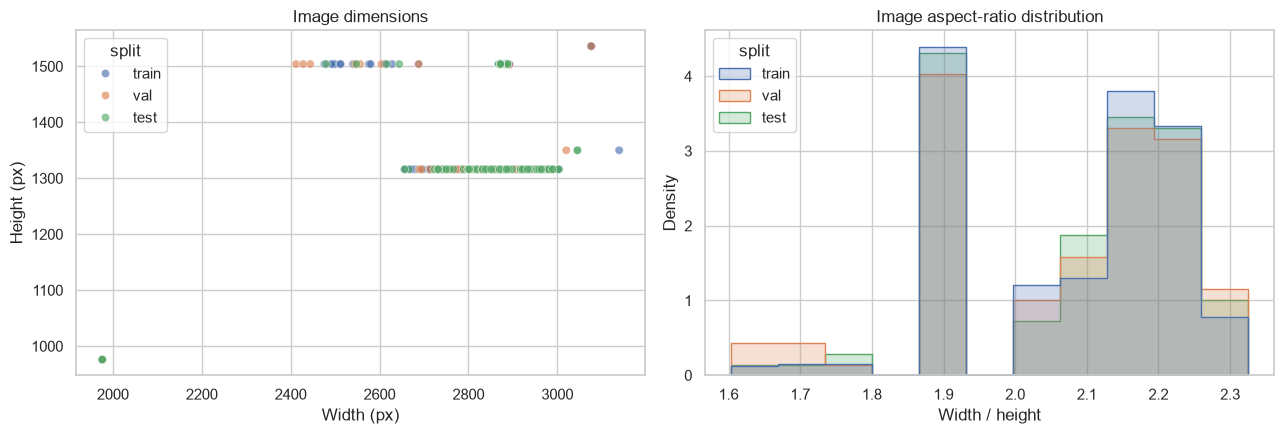

In [9]:
resolution_summary, common_resolutions = analyze_image_resolutions(images_df)

**Observation.** Width ranges from approximately 1,976 to 3,139 pixels and height from 976 to 1,536 pixels. The median dimensions are approximately $2872\times1316$ pixels. The most frequent exact resolution is $2872\times1504$, but it occurs in only 133 images, so it does not represent the entire dataset. Aspect ratios also vary, confirming that the panoramas are not geometrically identical.

**Preprocessing implication.** Naively resizing every image to a fixed square independently along both axes would distort panoramic anatomy and target-object shapes. Preprocessing should preserve aspect ratio through proportional resizing followed by padding or letterboxing. For source size $(W,H)$ and target canvas $(W_t,H_t)$,

$$
s = \min\left(\frac{W_t}{W},\frac{H_t}{H}\right),
\qquad
W'=sW,\quad H'=sH.
$$

The same scale and the padding offsets must be applied to bounding-box coordinates. EDA establishes this geometric requirement but does not determine the final input resolution; that choice must be tested experimentally against accuracy and computational cost.

## 5. Bounding-Box Geometry and Relative Size

For detection, object size relative to the complete image is more informative than raw pixel area when source resolutions differ. Relative bounding-box area is defined as

$$
a_{\mathrm{rel}} =
\frac{w_{\mathrm{box}}h_{\mathrm{box}}}
{W_{\mathrm{image}}H_{\mathrm{image}}}.
$$

This normalisation allows boxes from different panoramic resolutions to be compared on a common scale.

In [10]:
def analyze_bbox_geometry(annotations):
    """Bbox geometry and display its tables and visualizations."""
    box_summary = annotations[["bbox_width", "bbox_height", "bbox_area", "relative_area"]].describe().T[
        ["min", "25%", "50%", "mean", "75%", "max"]
    ]
    class_area_summary = annotations.groupby("class_name")["relative_area"].describe()[
        ["min", "25%", "50%", "mean", "75%", "max"]
    ].reindex(CLASS_NAMES.values())
    display(box_summary)
    display(class_area_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.histplot(data=annotations, x="relative_area", bins=40, ax=axes[0], color="#2a9d8f")
    axes[0].set(title="Bounding-box area relative to image", xlabel="Box area / image area", ylabel="Annotations")
    sns.boxplot(data=annotations, x="class_name", y="relative_area", order=CLASS_NAMES.values(), ax=axes[1])
    axes[1].set(title="Relative box area by pathology", xlabel="", ylabel="Box area / image area")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
    return box_summary, class_area_summary

,min,25%,50%,mean,75%,max
bbox_width,46.0123,131.0000,170.0000,175.1797,218.5185,363.0000
bbox_height,93.2432,249.5349,287.2727,279.8840,315.6667,538.4615
bbox_area,"8,228.5261","35,811.0000","46,288.0000","48,965.7737","60,742.0000","149,112.4260"
relative_area,0.0020,0.0093,0.0119,0.0126,0.0155,0.0370


,min,25%,50%,mean,75%,max
class_name,,,,,,
Impacted,0.0036,0.0088,0.0107,0.0109,0.0126,0.0218
Caries,0.0039,0.0097,0.0125,0.0132,0.0161,0.0296
Periapical Lesion,0.0032,0.0104,0.0141,0.0148,0.0186,0.0370
Deep Caries,0.0020,0.0084,0.0112,0.0118,0.0152,0.0279


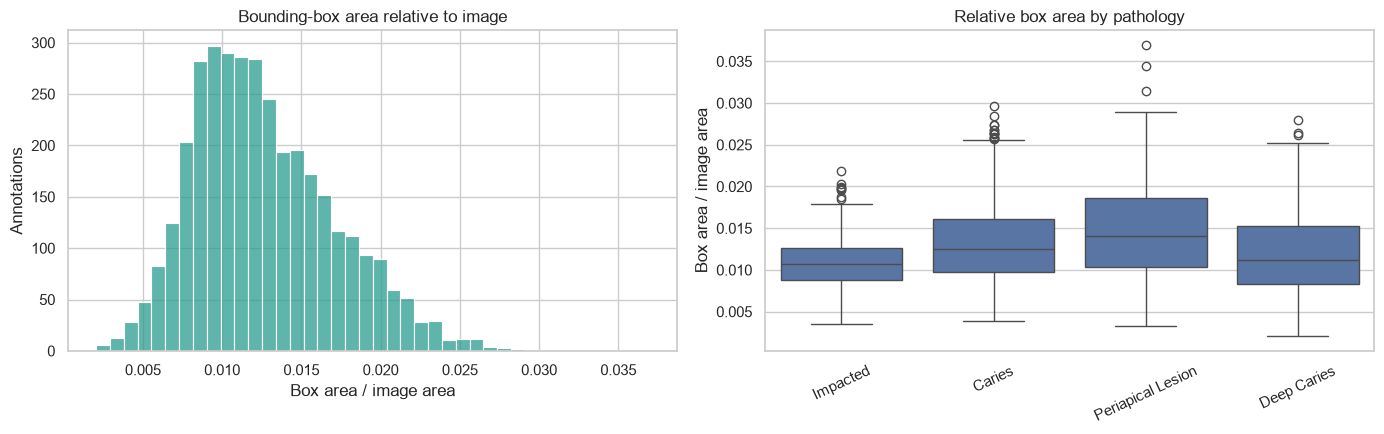

In [11]:
box_summary, class_area_summary = analyze_bbox_geometry(annotations_df)

**Observation.** Relative box area ranges from approximately 0.204% to 3.695% of image area, with an overall median of approximately 1.192%. The class-level distributions differ: Impacted has the lowest median relative area, while Periapical Lesion has the largest median, but the distributions overlap.

**Modeling implication.** Downscaling a panorama reduces the number of pixels representing each annotated region. Relative-area analysis is therefore needed before interpreting projected object sizes, but the median alone cannot determine the appropriate detector resolution or predict per-class performance.

## 6. Dataset-Relative Small Objects and Resolution Projection

To inspect the lower tail of the measured relative-area distribution, the notebook uses four DENTEX-specific analytical bands:

| Analytical band | Relative bounding-box area |
|---|---:|
| Very small | $a_{\mathrm{rel}} < 0.5\%$ |
| Small | $0.5\% \leq a_{\mathrm{rel}} < 1\%$ |
| Medium | $1\% \leq a_{\mathrm{rel}} < 2\%$ |
| Large | $a_{\mathrm{rel}} \geq 2\%$ |

These are internal categories for describing DENTEX, not universal definitions of small, medium, or large objects. They were selected after inspecting the actual distribution and make the composition of this dataset easier to compare across classes.

In [12]:
def analyze_small_objects(annotations):
    """Summarize DENTEX-relative object-size bands and plot class composition."""
    relative_quantiles = annotations["relative_area"].quantile([0, .01, .05, .10, .25, .50, .75, .90, .95, .99, 1])
    display(relative_quantiles.rename("relative_area").to_frame())

    size_bins = [-np.inf, 0.005, 0.01, 0.02, np.inf]
    size_labels = ["Very small (<0.5%)", "Small (0.5–<1%)", "Medium (1–<2%)", "Large (≥2%)"]
    annotations["size_band"] = pd.cut(annotations["relative_area"], bins=size_bins, labels=size_labels, right=False)
    size_counts = pd.crosstab(annotations["class_name"], annotations["size_band"]).reindex(index=CLASS_NAMES.values(), columns=size_labels, fill_value=0)
    size_percent = size_counts.div(size_counts.sum(axis=1), axis=0).mul(100)
    display(size_counts)
    display(size_percent.round(2))

    size_percent.plot(kind="bar", stacked=True, figsize=(10, 4.5), colormap="viridis")
    plt.title("Dataset-relative object-size composition by class")
    plt.xlabel("")
    plt.ylabel("Annotations (%)")
    plt.xticks(rotation=25)
    plt.legend(title="Size band", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    return relative_quantiles, size_counts, size_percent

,relative_area
0.0000,0.0020
0.0100,0.0044
0.0500,0.0064
0.1000,0.0075
0.2500,0.0093
0.5000,0.0119
0.7500,0.0155
0.9000,0.0191
0.9500,0.0209
0.9900,0.0248


size_band,Very small (<0.5%),Small (0.5–<1%),Medium (1–<2%),Large (≥2%)
class_name,,,,
Impacted,12,235,355,2
Caries,11,590,1398,190
Periapical Lesion,3,35,93,27
Deep Caries,35,197,312,34


size_band,Very small (<0.5%),Small (0.5–<1%),Medium (1–<2%),Large (≥2%)
class_name,,,,
Impacted,1.9900,38.9100,58.7700,0.3300
Caries,0.5000,26.9500,63.8600,8.6800
Periapical Lesion,1.9000,22.1500,58.8600,17.0900
Deep Caries,6.0600,34.0800,53.9800,5.8800


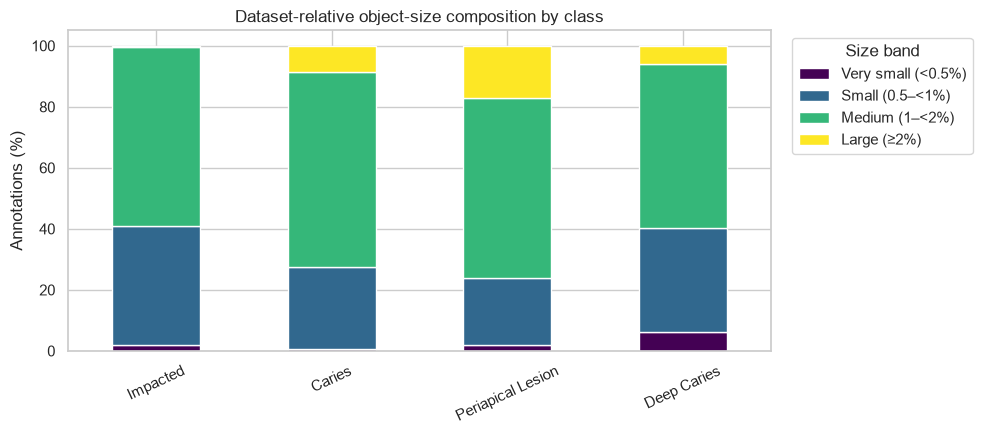

In [13]:
relative_quantiles, size_counts, size_percent = analyze_small_objects(annotations_df)

**Observation.** Only approximately 1.73% of all annotations occupy less than 0.5% of their image, while approximately 31.68% occupy less than 1%. Very small objects therefore do not dominate the dataset, but nearly one third of annotations fall within the two smallest internal bands. Deep Caries has the greatest very-small share: approximately 6.06% of its annotations are below 0.5% relative area.

To illustrate the effect of downscaling, the next calculation projects box dimensions onto 640 and 1024 square letterbox canvases while preserving aspect ratio. These are illustrative EDA projections only; neither value is selected here as the final model resolution.

In [14]:
def project_object_sizes(annotations, target_sizes=(640, 1024)):
    """Project box dimensions under aspect-preserving square letterbox scaling."""
    tables = []
    for target_size in target_sizes:
        scale = np.minimum(target_size / annotations["image_width"], target_size / annotations["image_height"])
        projected = annotations.assign(
            projected_width=annotations["bbox_width"] * scale,
            projected_height=annotations["bbox_height"] * scale,
        )
        projected["projected_short_side"] = projected[["projected_width", "projected_height"]].min(axis=1)
        summary = projected.groupby("class_name").agg(
            median_box_width_px=("projected_width", "median"),
            median_box_height_px=("projected_height", "median"),
            minimum_short_side_px=("projected_short_side", "min"),
        ).reindex(CLASS_NAMES.values()).reset_index()
        summary.insert(0, "canvas", f"{target_size}×{target_size}")
        tables.append(summary)
    return pd.concat(tables, ignore_index=True)

In [15]:
projection_table = project_object_sizes(annotations_df)
display(projection_table.round(1))

,canvas,class_name,median_box_width_px,median_box_height_px,minimum_short_side_px
0,640×640,Impacted,42.8000,48.5000,23.1000
1,640×640,Caries,37.0000,67.9000,13.5000
2,640×640,Periapical Lesion,42.6000,70.8000,12.8000
3,640×640,Deep Caries,36.1000,63.3000,11.1000
4,1024×1024,Impacted,68.4000,77.6000,37.0000
5,1024×1024,Caries,59.2000,108.6000,21.7000
6,1024×1024,Periapical Lesion,68.1000,113.3000,20.5000
7,1024×1024,Deep Caries,57.8000,101.3000,17.8000


**Modeling implication.** Increasing input resolution increases the number of pixels representing the same anatomical region, which may improve small-object localisation at the cost of memory and computation. Small-object detection is relevant to DENTEX, especially for Deep Caries, but it does not define the entire dataset. The presence of small boxes alone is not sufficient reason to select the maximum resolution or to treat 1024 as a final choice. Resolution must be compared empirically using overall and per-class metrics.

## 7. Bounding-Box Aspect Ratio

Bounding-box shape is described by

$$
r_{\mathrm{box}} = \frac{w}{h}.
$$

Values below 1 indicate boxes that are taller than they are wide; values closer to 1 indicate a more square shape. This is descriptive geometry, not an assumed predictive feature.

In [16]:
def analyze_bbox_aspect_ratios(annotations):
    """Bbox aspect ratios and display its tables and visualizations."""
    aspect_summary = annotations.groupby("class_name")["bbox_aspect_ratio"].describe()[
        ["min", "25%", "50%", "mean", "75%", "max"]
    ].reindex(CLASS_NAMES.values())
    display(aspect_summary)

    plt.figure(figsize=(10, 4.5))
    sns.boxplot(data=annotations, x="class_name", y="bbox_aspect_ratio", order=CLASS_NAMES.values(), showfliers=False)
    plt.title("Bounding-box aspect ratio by pathology")
    plt.xlabel("")
    plt.ylabel("Box width / height")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
    return aspect_summary

,min,25%,50%,mean,75%,max
class_name,,,,,,
Impacted,0.4358,0.7647,0.8887,0.9045,1.0145,1.6481
Caries,0.2048,0.4145,0.5446,0.5906,0.7509,1.4578
Periapical Lesion,0.1611,0.3784,0.5576,0.5964,0.7924,1.1429
Deep Caries,0.1779,0.4618,0.6078,0.6375,0.7909,1.4717


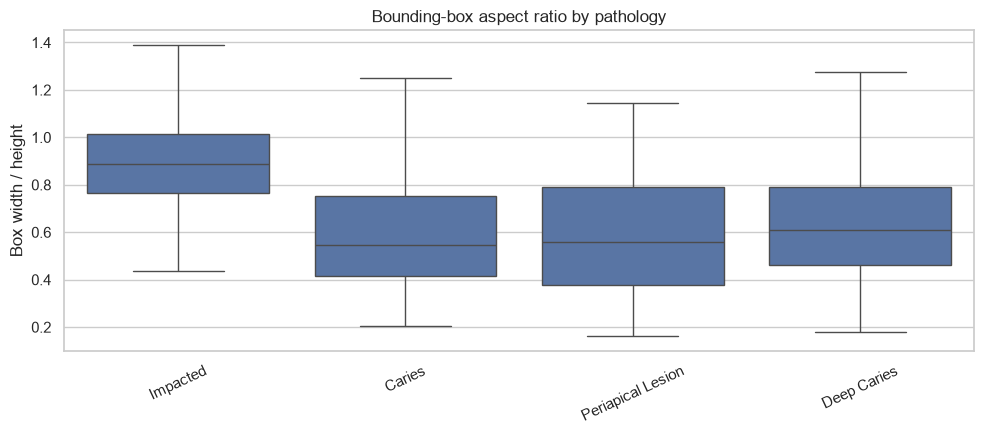

In [17]:
aspect_summary = analyze_bbox_aspect_ratios(annotations_df)

**Observation.** Median width-to-height ratios are approximately 0.54 for Caries, 0.56 for Periapical Lesion, and 0.61 for Deep Caries, so their typical boxes are taller than wide. Impacted has a median near 0.89 and is closer to square on average.

**Modeling implication.** The class distributions overlap substantially. Bounding-box aspect ratio alone is not a useful class discriminator and should not be treated as a class rule; it is one component of the geometry the detector must learn together with visual evidence.

## 8. Spatial Distribution of Objects

Absolute box coordinates are not directly comparable because source image dimensions vary. Each box center is therefore normalised as

$$
c_x = \frac{x+w/2}{W},
\qquad
c_y = \frac{y+h/2}{H},
$$

so that $c_x,c_y\in[0,1]$. Normalisation permits spatial patterns to be compared across panoramas of different resolutions.

In [18]:
def analyze_spatial_distribution(annotations):
    """Spatial distribution and display its tables and visualizations."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True, sharey=True)
    for axis, (class_id, class_name) in zip(axes, CLASS_NAMES.items()):
        subset = annotations[annotations["class_id"] == class_id]
        axis.hexbin(subset["center_x"], subset["center_y"], gridsize=20, extent=(0, 1, 0, 1), mincnt=1, cmap="magma")
        axis.set_title(class_name)
        axis.set_xlim(0, 1)
        axis.set_ylim(1, 0)
        axis.set_xlabel("Normalized x")
    axes[0].set_ylabel("Normalized y")
    fig.suptitle("Normalized bounding-box center density by class", y=1.04)
    plt.tight_layout()
    plt.show()

    spatial_summary = (
        annotations.groupby("class_name")[["center_x", "center_y"]]
        .agg(["mean", "std"]).reindex(CLASS_NAMES.values()).round(3)
    )
    display(spatial_summary)
    return spatial_summary

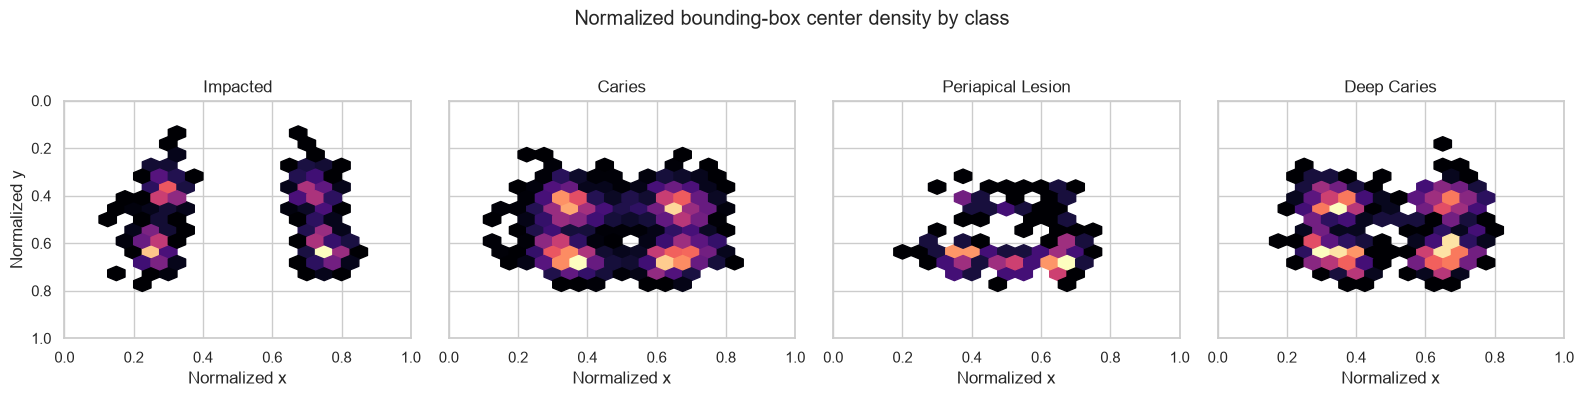

center_x        center_y       
                      mean    std     mean    std
class_name                                       
Impacted            0.5140 0.2360   0.5050 0.1340
Caries              0.5040 0.1670   0.5450 0.1190
Periapical Lesion   0.5190 0.1350   0.6050 0.1100
Deep Caries         0.4960 0.1700   0.5410 0.1200

In [19]:
spatial_summary = analyze_spatial_distribution(annotations_df)

**Observation.** All four classes occur on both the left and right sides of the panorama. Mean horizontal centers remain close to 0.5, and no simple left/right location rule separates the classes. Vertical distributions also overlap, although Periapical Lesion has a lower average position in the displayed image coordinate system, with mean $c_y\approx0.605$.

This is only a statistical property of the DENTEX annotations. It is not evidence of a general medical or anatomical rule outside this dataset; sample composition, acquisition, and dataset construction may influence the distribution.

**Augmentation implication.** Aggressive random cropping can partially or completely remove peripheral objects and may alter the representation of spatial regions. Geometric transformations should therefore be conservative and bounding-box-aware, with post-transform checks that valid boxes are retained.

## 9. Annotation Quality Audit

The integrity checks in `00_prepare_dataset.ipynb` established whether the processed dataset was technically valid. This EDA audit serves a different purpose: it searches for unusual or suspicious annotation patterns that may matter during training or later error analysis. It does not silently repair or remove any record.

In [20]:
def run_data_quality_audit(images, annotations):
    """Run data quality audit and display its tables and visualizations."""
    missing_files = images.loc[~images["image_path"].map(Path.is_file)]
    duplicate_image_ids = images.duplicated(["image_id"], keep=False)
    duplicate_annotation_ids = annotations.duplicated(["annotation_id"], keep=False)
    invalid_boxes = (annotations["bbox_width"] <= 0) | (annotations["bbox_height"] <= 0)
    outside_bounds = (
        (annotations["x"] < 0)
        | (annotations["y"] < 0)
        | (annotations["x"] + annotations["bbox_width"] > annotations["image_width"] + 1e-6)
        | (annotations["y"] + annotations["bbox_height"] > annotations["image_height"] + 1e-6)
    )
    duplicate_geometry_columns = ["image_id", "class_id", "x", "y", "bbox_width", "bbox_height"]
    exact_duplicate_geometry = annotations.duplicated(duplicate_geometry_columns, keep=False)
    extremely_tiny = annotations["relative_area"] < 0.001
    suspiciously_huge = annotations["relative_area"] > 0.10
    unusually_dense = images["num_objects"] > images["num_objects"].quantile(0.99)

    quality_report = pd.Series({
        "Missing image files": len(missing_files),
        "Records with duplicated image IDs": int(duplicate_image_ids.sum()),
        "Records with duplicated annotation IDs": int(duplicate_annotation_ids.sum()),
        "Invalid non-positive boxes": int(invalid_boxes.sum()),
        "Boxes outside image bounds": int(outside_bounds.sum()),
        "Annotations in exact-duplicate geometry groups": int(exact_duplicate_geometry.sum()),
        "Extremely tiny boxes (<0.1% image area)": int(extremely_tiny.sum()),
        "Suspiciously huge boxes (>10% image area)": int(suspiciously_huge.sum()),
        "Zero-annotation images": int((images["num_objects"] == 0).sum()),
        "Images above 99th percentile object count": int(unusually_dense.sum()),
    }, name="count").to_frame()
    display(quality_report)

    if exact_duplicate_geometry.any():
        display(
            annotations.loc[exact_duplicate_geometry,
                               ["split", "annotation_id", "image_id", "file_name", "class_name", "x", "y", "bbox_width", "bbox_height"]]
            .sort_values(["image_id", "class_name", "annotation_id"])
        )
    return quality_report, exact_duplicate_geometry

In [21]:
quality_report, exact_duplicate_geometry = run_data_quality_audit(images_df, annotations_df)

,count
Missing image files,0
Records with duplicated image IDs,0
Records with duplicated annotation IDs,0
Invalid non-positive boxes,0
Boxes outside image bounds,0
Annotations in exact-duplicate geometry groups,2
Extremely tiny boxes (<0.1% image area),0
Suspiciously huge boxes (>10% image area),0
Zero-annotation images,27
Images above 99th percentile object count,5


,split,annotation_id,image_id,file_name,class_name,x,y,bbox_width,bbox_height
1594,train,2335,447,train_377.png,Caries,"1,282.0000",774.0000,112.0000,292.0000
1596,train,2337,447,train_377.png,Caries,"1,282.0000",774.0000,112.0000,292.0000


**Observation.** The audit finds no missing image files, duplicate image IDs, duplicate annotation IDs, non-positive boxes, or boxes outside image boundaries. No annotation occupies less than 0.1% or more than 10% of its image. It confirms 27 valid negative images and identifies five images above the 99th percentile of object count as dense cases for visual review.

One exact-geometry group contains two annotations: IDs 2335 and 2337 on image 447 (`train_377.png`), both labelled Caries with identical coordinates. Exact geometry alone is insufficient evidence that either annotation is erroneous. The pair is retained unchanged as an unresolved manual-review case rather than being deleted automatically.

**Modeling implication.** No critical structural or geometric defect requires automatic correction. Negative images should be used for later false-positive analysis, while dense images and the duplicate-geometry case should remain candidates for targeted visual inspection and error analysis.

## 10. Representative Annotation Examples

Numerical summaries cannot establish whether bounding boxes visually align with the intended regions. A compact, evidence-driven gallery therefore displays actual processed radiographs selected from measured dataset properties: a typical-density image, the densest image, an image containing the rarest class, the image containing the smallest box, and a negative image where available. This provides direct visual checks of class coverage, alignment, sparse and dense cases, and unusual examples without producing an oversized gallery.

In [22]:
def analyze_representative_examples(images, annotations):
    """Representative examples and display its tables and visualizations."""
    def image_row_for_id(image_id):
        return images.loc[images["image_id"] == int(image_id)].iloc[0]


    def choose_examples():
        """Select examples from measured dataset properties, with stable tie-breaking."""
        median_count = images["num_objects"].median()
        typical = images.iloc[(images["num_objects"] - median_count).abs().argsort()].iloc[0]
        dense = images.sort_values(["num_objects", "image_id"], ascending=[False, True]).iloc[0]
        rare_class_id = int(annotations["class_id"].value_counts().idxmin())
        rare_image_id = annotations.loc[annotations["class_id"] == rare_class_id, "image_id"].min()
        smallest_image_id = annotations.loc[annotations["relative_area"].idxmin(), "image_id"]

        candidates = [
            ("Typical", typical),
            ("Many objects", dense),
            ("Rare class", image_row_for_id(rare_image_id)),
            ("Smallest box", image_row_for_id(smallest_image_id)),
        ]
        negatives = images[images["num_objects"] == 0].sort_values("image_id")
        if not negatives.empty:
            candidates.append(("Zero objects", negatives.iloc[0]))

        selected, seen = [], set()
        for label, row in candidates:
            key = (row["split"], int(row["image_id"]))
            if key not in seen:
                selected.append((label, row))
                seen.add(key)
        return selected


    def draw_annotated_image(axis, label, image_row):
        """Render one processed panorama and its boxes on an existing axis."""
        with Image.open(image_row["image_path"]) as image:
            axis.imshow(image.convert("L"), cmap="gray")
        boxes = annotations[
            (annotations["split"] == image_row["split"])
            & (annotations["image_id"] == image_row["image_id"])
        ]
        for box in boxes.itertuples():
            axis.add_patch(Rectangle(
                (box.x, box.y), box.bbox_width, box.bbox_height,
                fill=False, linewidth=1.8, edgecolor=CLASS_COLORS[box.class_id]
            ))
            axis.text(box.x, max(0, box.y - 5), box.class_name, color="white", fontsize=7,
                      bbox={"facecolor": CLASS_COLORS[box.class_id], "alpha": 0.8, "pad": 1})
        axis.set_title(f"{label}: {image_row['file_name']} ({len(boxes)} objects)")
        axis.axis("off")


    # Select and render the requested evidence-driven examples.
    examples = choose_examples()
    fig, axes = plt.subplots(len(examples), 1, figsize=(15, 4 * len(examples)))
    for axis, (label, image_row) in zip(np.atleast_1d(axes), examples):
        draw_annotated_image(axis, label, image_row)
    legend = [Patch(color=color, label=CLASS_NAMES[class_id]) for class_id, color in CLASS_COLORS.items()]
    fig.legend(handles=legend, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.005))
    plt.tight_layout()
    plt.show()
    return examples

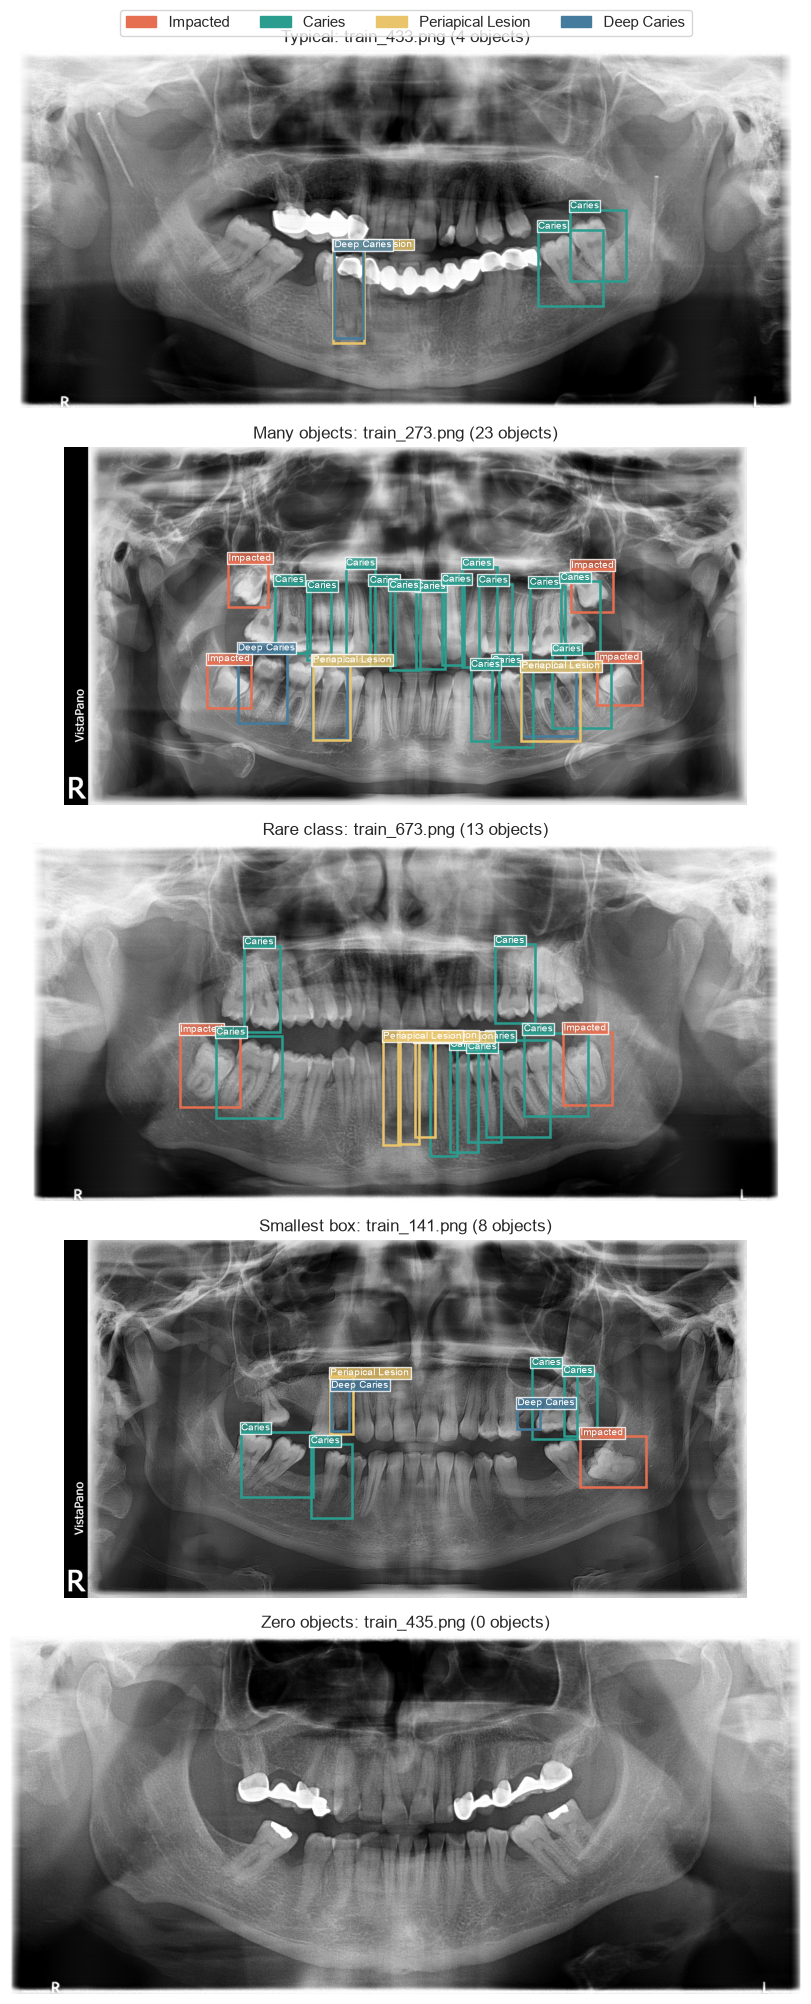

In [23]:
examples = analyze_representative_examples(images_df, annotations_df)

**Observation.** The examples show substantial variation in annotation density, including a 23-object panorama and a negative image. The rare-class and smallest-box cases demonstrate why dataset-level counts and geometry summaries should be supplemented by visual inspection.

**Modeling implication.** Automated integrity checks are necessary but cannot replace inspection of the underlying radiographs and bounding-box placement. These representative cases provide a reference set for preprocessing checks and later qualitative error analysis.

## 11. Train / Validation / Test Distribution Consistency

The fixed 70/15/15 split contains:

| Split | Images | Annotations |
|---|---:|---:|
| Train | 493 | 2,442 |
| Validation | 106 | 548 |
| Test | 106 | 539 |

Annotation totals need not follow the image proportions exactly because images contain different numbers of objects. Split quality must therefore be reviewed at several levels: annotation-level class share, image-level class presence, objects per image, relative bounding-box area, and image aspect ratio.

For split $s$ and class $c$, image-level class presence rate is

$$
p_{s,c} = \frac{N_{s,c}^{\mathrm{images}}}{N_s},
$$

where $N_{s,c}^{\mathrm{images}}$ is the number of images in split $s$ containing class $c$, and $N_s$ is the total number of images in that split. Instance-level and image-level comparisons are both needed because one image may contain multiple objects of the same class.

In [24]:
def analyze_split_quality(images, annotations):
    """Split quality and display its tables and visualizations."""
    instance_rate = pd.crosstab(annotations["class_name"], annotations["split"], normalize="columns").reindex(
        index=CLASS_NAMES.values(), columns=SPLIT_ORDER
    ).mul(100)

    presence_rate = pd.DataFrame({
        split: [
            100 * images.loc[images["split"] == split, f"has_{class_id}"].mean()
            for class_id in CLASS_NAMES
        ]
        for split in SPLIT_ORDER
    }, index=CLASS_NAMES.values())

    distribution_check = pd.DataFrame({
        "mean_objects": images.groupby("split")["num_objects"].mean(),
        "median_objects": images.groupby("split")["num_objects"].median(),
        "median_relative_box_area_pct": annotations.groupby("split")["relative_area"].median() * 100,
        "median_image_aspect_ratio": images.groupby("split")["aspect_ratio"].median(),
    }).reindex(SPLIT_ORDER)

    display(instance_rate.round(2).rename_axis("instance share (%)"))
    display(presence_rate.round(2).rename_axis("images containing class (%)"))
    display(distribution_check.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.ecdfplot(data=images, x="num_objects", hue="split", hue_order=SPLIT_ORDER, ax=axes[0])
    axes[0].set(title="Objects-per-image distribution", xlabel="Objects per image", ylabel="Cumulative proportion")
    sns.ecdfplot(data=annotations, x="relative_area", hue="split", hue_order=SPLIT_ORDER, ax=axes[1])
    axes[1].set(title="Relative box-area distribution", xlabel="Box area / image area", ylabel="Cumulative proportion")
    plt.tight_layout()
    plt.show()
    return instance_rate, presence_rate, distribution_check

split,train,val,test
instance share (%),,,
Impacted,16.7500,18.0700,17.8100
Caries,61.4700,64.7800,61.7800
Periapical Lesion,4.4600,4.2000,4.8200
Deep Caries,17.3200,12.9600,15.5800


,train,val,test
images containing class (%),,,
Impacted,36.1100,35.8500,35.8500
Caries,88.4400,87.7400,88.6800
Periapical Lesion,16.2300,16.9800,16.9800
Deep Caries,45.6400,45.2800,45.2800


,mean_objects,median_objects,median_relative_box_area_pct,median_image_aspect_ratio
split,,,,
train,4.9530,4.0000,1.1850,2.1340
val,5.1700,4.0000,1.1990,2.1310
test,5.0850,4.0000,1.2370,2.1290


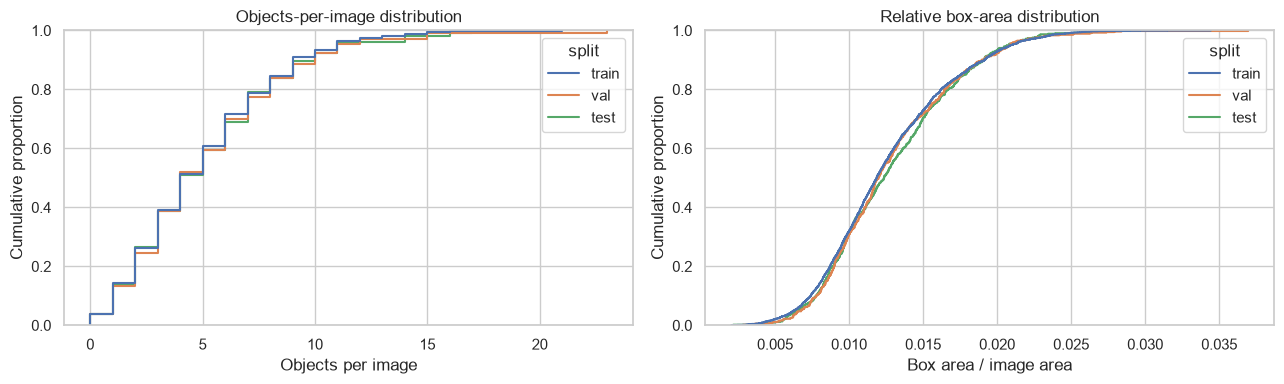

In [25]:
instance_rate, presence_rate, distribution_check = analyze_split_quality(images_df, annotations_df)

**Observation.** Annotation-level class shares and image-level presence rates remain broadly similar across train, validation, and test. Median object count is 4 in every split. Median relative box area is approximately 1.185%, 1.199%, and 1.237%, while median image aspect ratio is approximately 2.134, 2.131, and 2.129. The ECDF plots likewise show closely aligned objects-per-image and relative-area distributions.

No substantial distribution shift was observed in the analysed aggregate dataset characteristics. This is a descriptive conclusion, not formal proof that the distributions are identical. The current multilabel-aware split has met its practical balancing objective and should remain fixed.

Validation contains only 23 Periapical Lesion annotations. With so few examples, several additional correct or incorrect detections can materially change per-class AP or Recall. Small validation changes for this class should not be overinterpreted during model selection; decisions should use the combined overall and per-class evidence.

In [26]:
assert DATA_ROOT == PROJECT_ROOT / "data" / "processed" / "dentex_diagnosis"
assert len(images_df) == 705
assert len(annotations_df) == 3529
assert images_df.groupby("split").size().reindex(SPLIT_ORDER).to_dict() == {"train": 493, "val": 106, "test": 106}
assert annotations_df.groupby("split").size().reindex(SPLIT_ORDER).to_dict() == {"train": 2442, "val": 548, "test": 539}
assert set(annotations_df["class_id"]) == set(CLASS_NAMES)
assert all(path.is_file() for path in images_df["image_path"])
assert int(quality_report.loc["Annotations in exact-duplicate geometry groups", "count"]) == 2

verification = pd.DataFrame({"Status": ["Passed"] * 5}, index=[
    "Canonical read-only path", "Image and annotation totals", "Fixed split counts",
    "Four-class coverage", "Exact-geometry case retained",
])
display(verification)

,Status
Canonical read-only path,Passed
Image and annotation totals,Passed
Fixed split counts,Passed
Four-class coverage,Passed
Exact-geometry case retained,Passed


## 12. EDA Conclusions and Modeling Decisions

The EDA supports the following decisions for subsequent preprocessing, baseline modeling, evaluation, and error analysis:

- **Class imbalance:** Periapical Lesion is strongly underrepresented with 158 annotations. Overall metrics must be supplemented with per-class AP and recall-oriented diagnostics. Balancing methods should not be introduced automatically before baseline behaviour is measured.
- **Image geometry:** Source resolution and aspect ratio vary. Preprocessing should preserve aspect ratio through proportional resizing and padding or letterboxing, with the same transformation applied to bounding boxes.
- **Small objects:** Almost one third of annotations occupy less than 1% of image area, but very small objects do not dominate the dataset. Candidate input resolutions should be compared experimentally rather than selected from EDA alone.
- **Spatial distribution:** Target objects appear throughout the panorama. Aggressive geometric augmentation, particularly uncontrolled random cropping, should be avoided unless transformed bounding boxes are validated.
- **Negative images:** All 27 negative images should remain in the dataset and later support dedicated false-positive analysis.
- **Annotation quality:** No critical structural annotation defect was found. The exact-geometry pair remains unchanged as an unresolved manual-review case.
- **Split consistency:** No substantial aggregate distribution shift was observed, so the current train/validation/test assignment should remain fixed. Rare-class validation metrics, especially the 23 Periapical Lesion annotations, require cautious interpretation.

The canonical dataset is therefore ready for aspect-ratio-preserving preprocessing and baseline detector experiments. Later modeling should compare input resolution empirically, report both overall and per-class performance, and retain focused diagnostics for rare classes, small objects, dense images, and negative images.